In [54]:
import pandas as pd
df = pd.read_csv(r"C:\Users\Marina\genres\ast_model\wandb_logs\\wandb_hyper_11.csv")
df.head()

,Name,State,Created,freeze_layers,eval/accuracy,batch_size,normalisation,activation_fn,dropout_top,learning_rate
0,trial_54,finished,2025-07-23T19:49:31.000Z,8,0.657767,4,layer,relu,0.069267,0.000018
1,trial_53,finished,2025-07-23T19:37:06.000Z,3,0.665049,4,layer,none,0.064907,0.000010
2,trial_52,finished,2025-07-23T19:24:14.000Z,0,0.655340,4,layer,gelu,0.000143,0.000042
3,trial_51,finished,2025-07-23T19:10:15.000Z,3,0.655340,4,none,relu,0.039777,0.000013
4,trial_50,finished,2025-07-23T19:03:05.000Z,7,0.638350,4,none,relu,0.081114,0.000010


In [55]:
len(df)

54

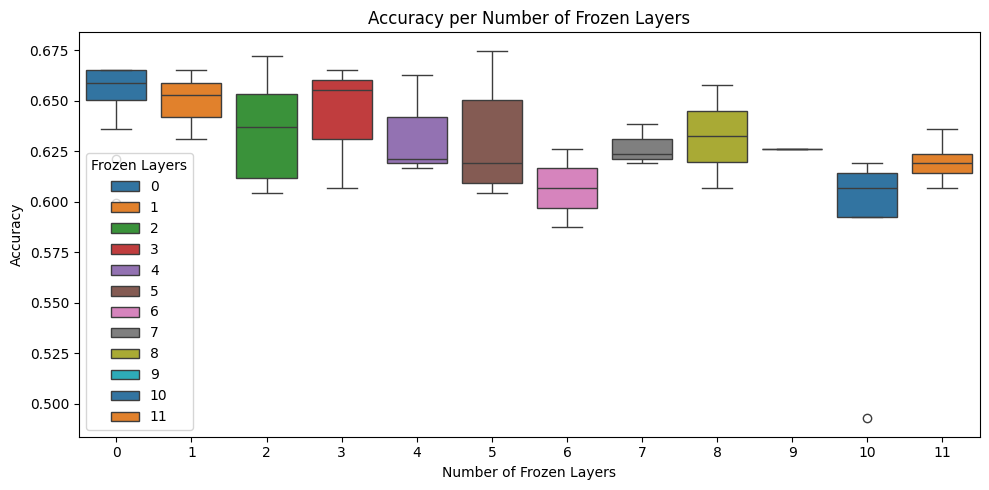

In [56]:
import seaborn as sns  # with 11
import matplotlib.pyplot as plt
#df['hyperparams.freeze_layers'] = df['hyperparams.freeze_layers'].astype(str)  # or use Categorical if you want specific order

# Create the plot
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='freeze_layers', y='eval/accuracy', hue='freeze_layers',  palette='tab10')

# Adjust plot
plt.xlabel("Number of Frozen Layers")
plt.ylabel("Accuracy")
plt.title("Accuracy per Number of Frozen Layers")
plt.legend(title="Frozen Layers")
plt.tight_layout()
plt.show()

C:\Users\Marina\AppData\Local\Temp\ipykernel_17284\3648468556.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Frozen Layers")


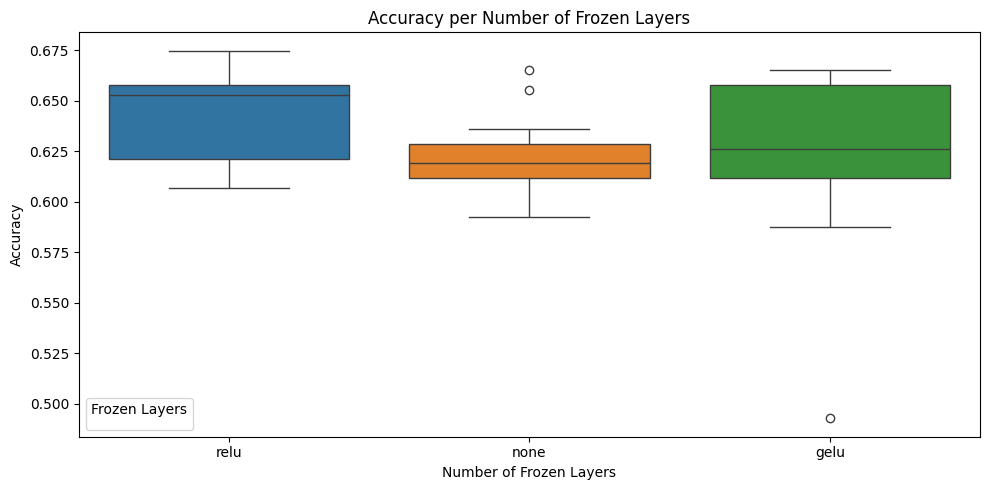

In [57]:
import seaborn as sns  # with 11
import matplotlib.pyplot as plt
#df['hyperparams.freeze_layers'] = df['hyperparams.freeze_layers'].astype(str)  # or use Categorical if you want specific order

# Create the plot
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='activation_fn', y='eval/accuracy', hue='activation_fn',  palette='tab10')

# Adjust plot
plt.xlabel("Number of Frozen Layers")
plt.ylabel("Accuracy")
plt.title("Accuracy per Number of Frozen Layers")
plt.legend(title="Frozen Layers")
plt.tight_layout()
plt.show()

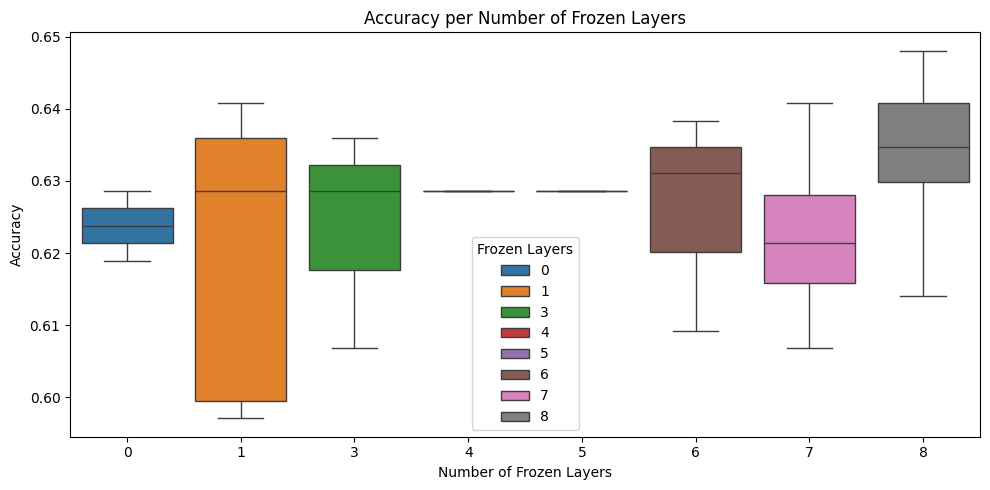

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
#df['hyperparams.freeze_layers'] = df['hyperparams.freeze_layers'].astype(str)  # or use Categorical if you want specific order

# Create the plot
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='freeze_layers', y='eval/accuracy', hue='freeze_layers',  palette='tab10')

# Adjust plot
plt.xlabel("Number of Frozen Layers")
plt.ylabel("Accuracy")
plt.title("Accuracy per Number of Frozen Layers")
plt.legend(title="Frozen Layers")
plt.tight_layout()
plt.show()

C:\Users\Marina\AppData\Local\Temp\ipykernel_17284\744773637.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Frozen Layers")


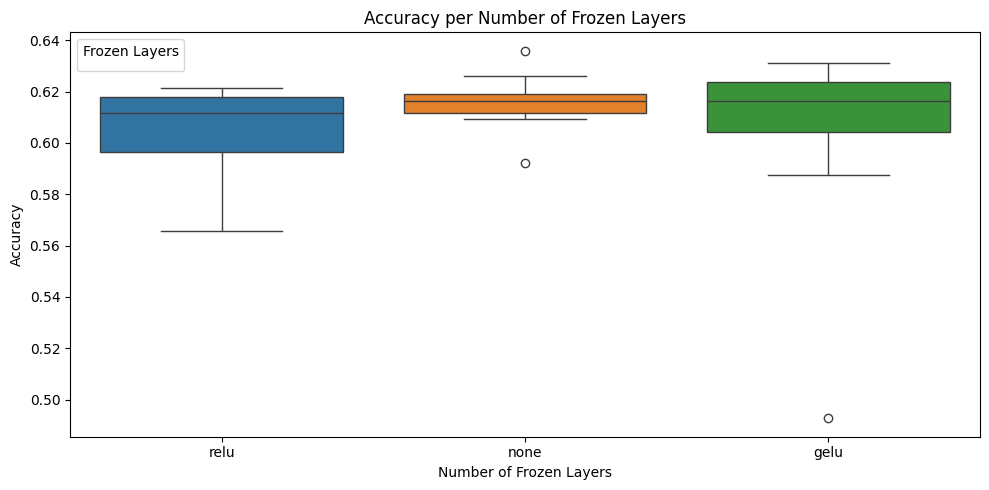

In [29]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='activation_fn', y='eval/accuracy', hue='activation_fn',  palette='tab10')

# Adjust plot
plt.xlabel("Number of Frozen Layers")
plt.ylabel("Accuracy")
plt.title("Accuracy per Number of Frozen Layers")
plt.legend(title="Frozen Layers")
plt.tight_layout()
plt.show()

C:\Users\Marina\AppData\Local\Temp\ipykernel_17284\3007680202.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=[str(k) for k in df[col].unique()])
C:\Users\Marina\AppData\Local\Temp\ipykernel_17284\3007680202.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=[str(k) for k in df[col].unique()])
C:\Users\Marina\AppData\Local\Temp\ipykernel_17284\3007680202.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=[str(k) for k in df[col].unique()])


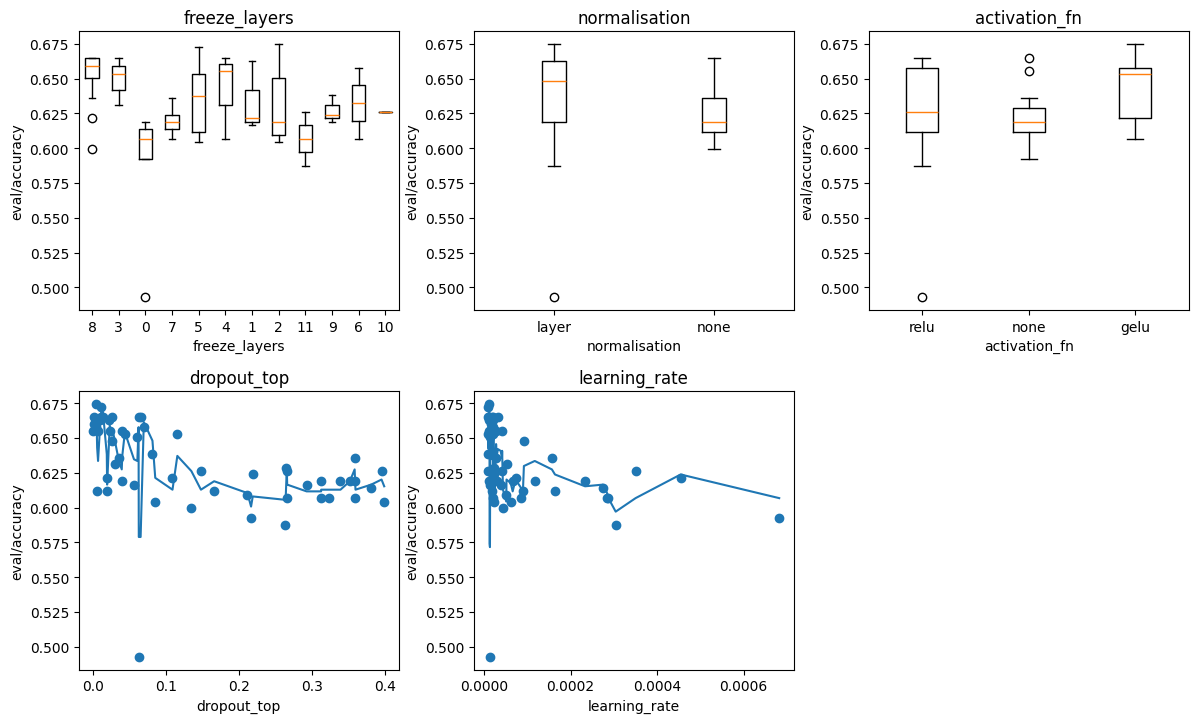

In [61]:
import math
import pandas as pd
import matplotlib.pyplot as plt

# df should have: ["freeze_layers","normalisation","activation_fn","dropout_top",
#                  "learning_rate","accuracy"]
df['freeze_layers'] = df['freeze_layers'].astype(str) 
params = ["freeze_layers","normalisation","activation_fn","dropout_top","learning_rate"]
n = len(params)
rows = cols = math.ceil(math.sqrt(n))

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3.5*rows))
axes = axes.flatten()

def plot_param(ax, df, col):
    y = "eval/accuracy"
    if pd.api.types.is_numeric_dtype(df[col]):
        ax.scatter(df[col], df[y])
        # optional: running mean to see trend
        df_sorted = df.sort_values(col)
        rolling = df_sorted[y].rolling(window=max(1,len(df)//20), min_periods=1).mean()
        ax.plot(df_sorted[col], rolling)
        ax.set_xlabel(col)
        ax.set_ylabel(y)
    else:
        # categorical: show boxplots (or strip)
        groups = [g[y].values for _, g in df.groupby(col)]
        ax.boxplot(groups, labels=[str(k) for k in df[col].unique()])
        ax.set_xlabel(col)
        ax.set_ylabel(y)
    ax.set_title(col)

for i, p in enumerate(params):
    plot_param(axes[i], df, p)

# remove empty axes (if any)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()
plt.show()


In [58]:
import pandas as pd
from scipy import stats
from sklearn.feature_selection import mutual_info_regression

y = df["eval/accuracy"].values
num = ["learning_rate", "dropout_top", "freeze_layers"]  # if numeric
cat = ["normalisation", "activation_fn"]

# Spearman
spearman = {c: stats.spearmanr(df[c], y, nan_policy="omit").correlation for c in num}

# Mutual information (handles non-linear)
mi = mutual_info_regression(df[num], y, random_state=0)
mi = dict(zip(num, mi))

# ANOVA eta-squared for categorical
def eta_squared(cat_col):
    groups = [g["eval/accuracy"].values for _, g in df.groupby(cat_col)]
    f, p = stats.f_oneway(*groups)
    ss_between = sum(len(g)*((g.mean()-y.mean())**2) for g in groups)
    ss_total = ((y - y.mean())**2).sum()
    return ss_between/ss_total
etas = {c: eta_squared(c) for c in cat}


In [59]:
etas

{'normalisation': 0.028228199881286057, 'activation_fn': 0.0642855178043646}

In [60]:
spearman

{'learning_rate': -0.5576945994797304,
 'dropout_top': -0.6245140948302389,
 'freeze_layers': -0.5095529929366036}

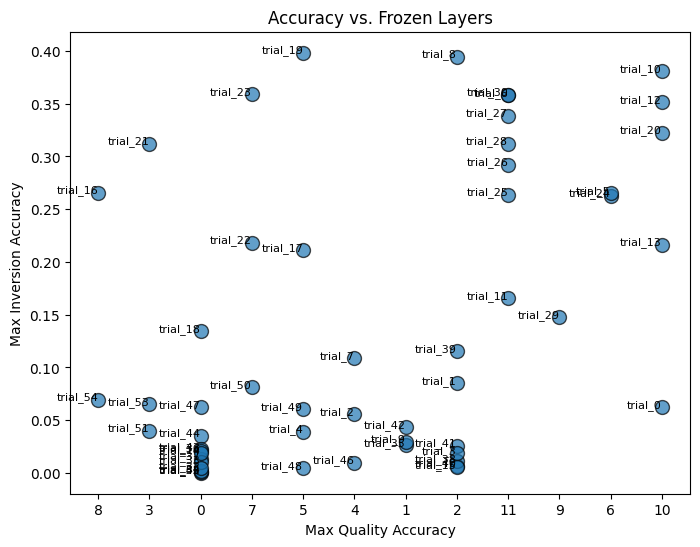

In [75]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    df["freeze_layers"],
    df["dropout_top"],
    s=100,  # bigger size for fewer frozen layers
    alpha=0.7,
    edgecolor='k'
)

plt.xlabel('Max Quality Accuracy')
plt.ylabel('Max Inversion Accuracy')
plt.title('Accuracy vs. Frozen Layers')

# Optional: add trial names
for i, row in df.iterrows():
    plt.text(
        row["freeze_layers"],
        row["dropout_top"],
        row['Name'],
        fontsize=8,
        ha='right'
    )

#plt.grid(True)
plt.show()

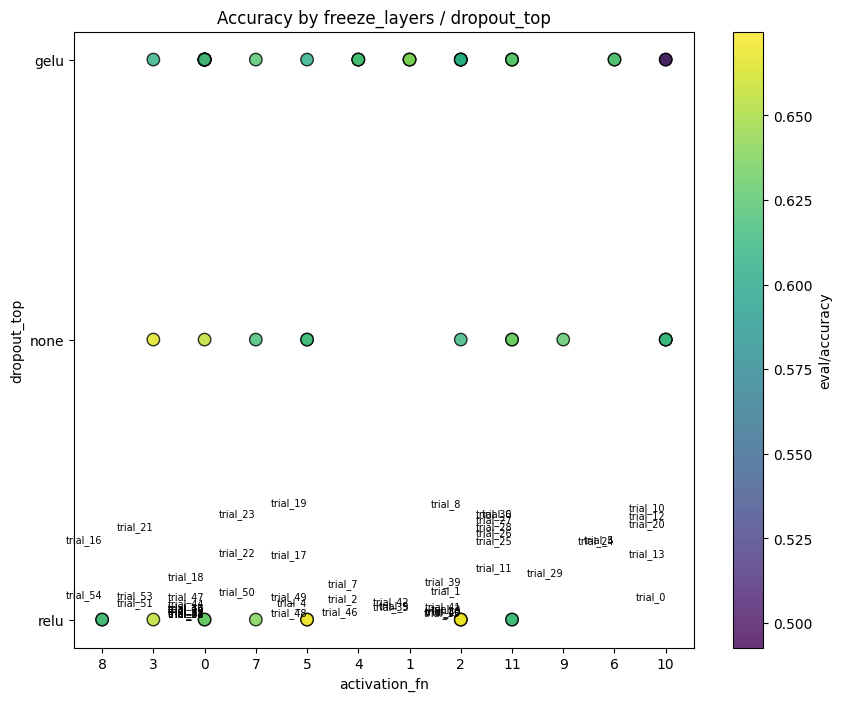

In [81]:
fig, ax = plt.subplots(figsize=(10, 8))

sc = ax.scatter(
    df["freeze_layers"],
    df["activation_fn"],
    s=80,                               # constant size
    c=df["eval/accuracy"],              # color = accuracy
    cmap="viridis",
    alpha=0.8,
    edgecolors="k"
)

ax.set_xlabel("activation_fn")
ax.set_ylabel("dropout_top")
ax.set_title("Accuracy by freeze_layers / dropout_top")
fig.colorbar(sc, ax=ax, label="eval/accuracy")

for _, row in df.iterrows():
    ax.text(row["freeze_layers"], row["dropout_top"], row["Name"],
            fontsize=7, ha="right", va="bottom")